In [10]:
import numpy as np
from gplearn.functions import make_function
from gplearn.functions import _Function
import matplotlib.pyplot as plt

from primel.adapters.gplearn import GPLearnAdapter, ImplicitSymbolicRegressor
from primel.distributions import (
    Empirical,
    GaussianKDE,
    MultivariateUniform,
)
from primel.early_stopping import EarlyStopping
from primel.fitness import induced_kl_divergence
from primel.tree import ExpressionTree, Node, simplify_tree
from primel.samplers import (
    ImportanceSampler,
    LHSampler,
    RandomSampler,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
def _build_tree(program: list) -> ExpressionTree:
    """Build an ExpressionTree from a gplearn program representation.

    Parameters
    ----------
    program : list
        The gplearn program representation as a list of nodes.

    Returns
    -------
    ExpressionTree
        The constructed ExpressionTree.

    """
    nodes = []
    for node in program:
        if isinstance(node, _Function):
            nodes.append(Node(name=node.name, value=node.function, arity=node.arity))
        elif isinstance(node, int):
            nodes.append(
                Node(name=f"x{node}", value=lambda x, n=node: x[:, n], arity=0)
            )
        elif isinstance(node, float):
            nodes.append(Node(name="constant", value=node, arity=0))

    return ExpressionTree.init_from_list(nodes)


In [12]:
def _protected_division(x1, x2):
    """Closure of division (x1/x2) for zero denominator."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(x2) > 1e-10, np.divide(x1, x2), 1.0)


def _protected_log(x1):
    """Closure of log for zero and negative arguments."""
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(x1) > 1e-10, np.log(np.abs(x1)), 0.0)


_div2 = make_function(function=_protected_division, name="div", arity=2)
_log1 = make_function(function=_protected_log, name="log", arity=1)

In [13]:
data_path = "../data/zhong/f01/f01.csv"
data = np.loadtxt(data_path, delimiter=",")

In [14]:
print(f"x min: {data[:, 0].min()}, x max: {data[:, 0].max()}")

x min: -1.0, x max: 1.0


In [15]:
config = {
    "model__n_kde": 484,
    "model__n_uniform": 58,
    "model__kde_bandwidth": 1.9094831321020118,
    "random_state": 8322,
}

In [16]:
empirical_dist = Empirical(data=data)
gaussian_kde_dist = GaussianKDE(
    X=data, bandwidth=config["model__kde_bandwidth"]
)

uniform_dist = MultivariateUniform(X=data, margins=0.1, non_negative=False)

sampler_entries = [
    ("train", RandomSampler(empirical_dist), data.shape[0]),
    ("kde", RandomSampler(gaussian_kde_dist), config["model__n_kde"]),
    ("uniform", LHSampler(uniform_dist), config["model__n_uniform"]),
]

sampler = ImportanceSampler(
    sampler_entries=sampler_entries, random_state=42,
)

<Figure size 1000x800 with 0 Axes>

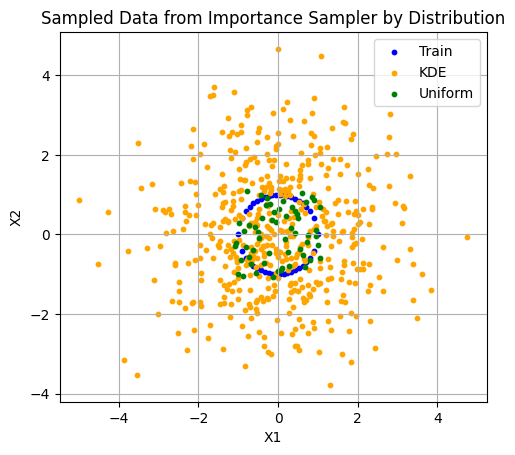

In [17]:
from_train = sampler.get_samples("train")
from_kde = sampler.get_samples("kde")
from_uniform = sampler.get_samples("uniform")

plt.figure(figsize=(10, 8))
fig, ax = plt.subplots()
ax.scatter(from_train[:, 0], from_train[:, 1], s=10, color="blue", label="Train")
ax.scatter(from_kde[:, 0], from_kde[:, 1], s=10, color="orange", label="KDE")
ax.scatter(from_uniform[:, 0], from_uniform[:, 1], s=10, color="green", label="Uniform")
ax.set_title("Sampled Data from Importance Sampler by Distribution")
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_aspect('equal')
ax.grid(True)
ax.legend()

plt.show()

In [24]:
early_stopping = EarlyStopping(
    sampler=sampler,
    train_X="train",
    total_variance_threshold=1e-4,
    training_variance_threshold=1e-6,
)

adapter = GPLearnAdapter(
    sampler=sampler,
    reference_distribution=gaussian_kde_dist,
    early_stopping=early_stopping,
    mean_center_on="train",
    lambda_=1.0,
    exponent=1.0,
)

model = ImplicitSymbolicRegressor(
    function_set=[
        "add",
        "sub",
        "mul",
        _div2,
        "sin",
        "cos",
        "tan",
        "sqrt",
        _log1,
    ],
    adapter=adapter,
    max_length=100,
    population_size=1000,
    generations=100,
    parsimony_coefficient="auto",
    verbose=1,
    low_memory=True,
    random_state=config["random_state"],
)

model.fit(
    sampler.samples, 
    np.zeros(sampler.samples.shape[0]),
    X_val=from_train,
)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
original program: [<gplearn.functions._Function object at 0x7fff84a26e10>, <gplearn.functions._Function object at 0x7fff84a274d0>, 1, <gplearn.functions._Function object at 0x7fff84a26e10>, <gplearn.functions._Function object at 0x7fff84a26cf0>, <gplearn.functions._Function object at 0x7fff84a26e10>, <gplearn.functions._Function object at 0x7fff84a26cf0>, 0]
simplified program: [<gplearn.functions._Function object at 0x7fff84ac1010>, <gplearn.functions._Function object at 0x7fff84ac2ab0>, 1, <gplearn.functions._Function object at 0x7fff84ac3cb0>, <gplearn.functions._Function object at 0x7fff84ac2930>, 0]
original program: [<gplearn.functions._Function object at 0x7fff84a27890>, <gplearn.functions._Function object at 0x7fff84a27890>, 0.9416745305

IndexError: list index out of range

In [ ]:
# model._program.__str__()
simple_tree = _build_tree(model._program.program)
simplify_tree(simple_tree, data)

In [ ]:
print(simple_tree)

mul
	x0
	x1

